In [266]:
import os
import math
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq

In [267]:
from dotenv import load_dotenv
import os

load_dotenv()

from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.1-8b-instant")

In [268]:
llm.invoke("hi").content

'How can I assist you today?'

In [269]:
from langgraph.graph import StateGraph,MessagesState, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, Literal, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

In [270]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}    

In [271]:
workflow=StateGraph(MessagesState)
workflow.add_node("chatbot",call_model)
workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot",END)
app=workflow.compile()

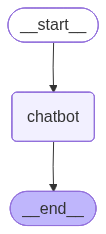

In [272]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [273]:
input={"messages":["Hi, This is Sarathi"]}

In [274]:
app.invoke(input)

{'messages': [HumanMessage(content='Hi, This is Sarathi', additional_kwargs={}, response_metadata={}, id='6f42c805-35cf-4905-b393-b0e297829fa8'),
  AIMessage(content="Hello Sarathi, how are you? It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 41, 'total_tokens': 72, 'completion_time': 0.049339367, 'completion_tokens_details': None, 'prompt_time': 0.003365813, 'prompt_tokens_details': None, 'queue_time': 0.051095127, 'total_time': 0.05270518}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8902-bd44-7c82-9f0a-40b798d53673-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 31, 'total_tokens': 72})]}

In [275]:
for output in app.stream(input):
    for key,value in output.items():
        print(f"Output from {key} Node")
        print("_______")
        print(value)
        print("\n")

Output from chatbot Node
_______
{'messages': [AIMessage(content="Hello Sarathi, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.034659423, 'completion_tokens_details': None, 'prompt_time': 0.003857892, 'prompt_tokens_details': None, 'queue_time': 0.077575368, 'total_time': 0.038517315}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8902-bdf3-7bb1-a012-6adfd8223233-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 27, 'total_tokens': 68})]}




In [ ]:
#Custom tool example

@tool
def search(query: str):
    """this is my custom tool."""
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "It's 60 degrees and foggy."
    return "It's 90 degrees and sunny."

In [277]:
search.invoke("what is a temprature in sf?")

"It's 60 degrees and foggy."

In [278]:
search.invoke("what is a weather in india?")

"It's 90 degrees and sunny."

In [279]:
search

StructuredTool(name='search', description='this is my custom tool.', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001E6CE7FB420>)

In [280]:
tools=[search]

In [281]:
tool_node=ToolNode(tools)

In [282]:
llm_with_tool=llm.bind_tools(tools)

In [283]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm_with_tool.invoke(messages)
    return {"messages": [response]}

In [284]:
#response=call_model({"messages": ["hi how are you?"]})

In [285]:
print(llm_with_tool)

bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E6CEA40D60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E6CEA41F30>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')) kwargs={'tools': [{'type': 'function', 'function': {'name': 'search', 'description': 'this is my custom tool.', 'parameters': {'properties': {'query': {'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}]} config={} config_factories=[]


bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E6CB295A90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E6CB2967B0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')) kwargs={'tools': [{'type': 'function', 'function': {'name': 'search', 'description': 'this is my custom tool.', 'parameters': {'properties': {'query': {'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}]} config={} config_factories=[]

In [286]:
print(search.name)

search


In [287]:
llm_with_tool = llm.bind_tools(
    [search],
    tool_choice="search"
)

In [288]:
response = llm_with_tool.invoke(
    [HumanMessage(content="What is the weather in India?")]
)

print(response.tool_calls)

[{'name': 'search', 'args': {'query': 'current weather in India'}, 'id': 'pnps4zb9n', 'type': 'tool_call'}]


In [289]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pnps4zb9n', 'function': {'arguments': '{"query":"current weather in India"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 231, 'total_tokens': 244, 'completion_time': 0.030251806, 'completion_tokens_details': None, 'prompt_time': 0.014486506, 'prompt_tokens_details': None, 'queue_time': 0.332585761, 'total_time': 0.044738312}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6a1eabf260', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8902-bf96-7c30-995d-397f43526fc6-0', tool_calls=[{'name': 'search', 'args': {'query': 'current weather in India'}, 'id': 'pnps4zb9n', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 231, 'output_tokens': 13, 'total_tokens': 244})

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'f6qtbey0m', 'function': {'arguments': '{"query":"India weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 231, 'total_tokens': 242, 'completion_time': 0.046332439, 'completion_tokens_details': None, 'prompt_time': 0.035560412, 'prompt_tokens_details': None, 'queue_time': 0.161033166, 'total_time': 0.081892851}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e88e6-0291-7b90-b864-590c4ca14c52-0', tool_calls=[{'name': 'search', 'args': {'query': 'India weather'}, 'id': 'f6qtbey0m', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 231, 'output_tokens': 11, 'total_tokens': 242})


In [306]:
state = {
    "messages": [
        HumanMessage(content="Hi how are u?")
    ]
}

result = app.invoke(state)

print(result)

{'messages': [HumanMessage(content='Hi how are u?', additional_kwargs={}, response_metadata={}, id='0468d39f-2f09-4e0d-bb57-ba718d76965f'), AIMessage(content="I'm functioning properly, thanks for asking. How can I assist you?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 207, 'total_tokens': 223, 'completion_time': 0.039138312, 'completion_tokens_details': None, 'prompt_time': 0.044112482, 'prompt_tokens_details': None, 'queue_time': 0.070572678, 'total_time': 0.083250794}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8904-01fb-7640-9170-8ef2e47ac5dc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 207, 'output_tokens': 16, 'total_tokens': 223})]}


In [307]:
response = llm.invoke("Hi how are you?")
print(response.content)

I'm just a language model, so I don't have emotions or feelings like humans do. However, I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?


In [308]:
from langchain_core.tools import tool

@tool
def search(query: str) -> str:
    """Search something."""
    return "Sunny"

llm_with_tool = llm.bind_tools([search])

response = llm_with_tool.invoke("weather in india")

print(response)
print(response.tool_calls)

content='' additional_kwargs={'tool_calls': [{'id': 'bb6mcs6p7', 'function': {'arguments': '{"query":"India weather"}', 'name': 'search'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 205, 'total_tokens': 219, 'completion_time': 0.031036435, 'completion_tokens_details': None, 'prompt_time': 0.017646964, 'prompt_tokens_details': None, 'queue_time': 0.052021466, 'total_time': 0.048683399}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e8904-09d1-7893-a6fa-ada682b40f86-0' tool_calls=[{'name': 'search', 'args': {'query': 'India weather'}, 'id': 'bb6mcs6p7', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 205, 'output_tokens': 14, 'total_tokens': 219}
[{'name': 'search', 'args': {'query': 'India weather'}, 'id': 'bb6mcs6p7', 'type': 'tool_call'}]


In [309]:
HumanMessage(content="What is the weather in India?")

HumanMessage(content='What is the weather in India?', additional_kwargs={}, response_metadata={})

In [310]:
for event in app.stream(
    {"messages": ["what is the weather in India?"]}
):
    print(event)

{'agent': {'messages': [AIMessage(content="I don't have a function to retrieve real-time weather information for a specific country. However, I can try searching the web for the information.\n\n", additional_kwargs={'tool_calls': [{'id': '31dnf9rvs', 'function': {'arguments': '{"query":"current weather in India"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 209, 'total_tokens': 254, 'completion_time': 0.130532911, 'completion_tokens_details': None, 'prompt_time': 0.014567707, 'prompt_tokens_details': None, 'queue_time': 0.049640973, 'total_time': 0.145100618}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8904-127b-7f70-9602-de95ca6d09c1-0', tool_calls=[{'name': 'search', 'args': {'query': 'current weather in India'}, 'id': '31dnf9rvs', 'type': 'tool_call'}], in

In [311]:
def router_function(state: MessagesState) -> Literal["tools", END]:
    #print(f"here is a state from should continue {state}")
    messages = state['messages']
    last_message = messages[-1]
    #print(f"here is a last message from should continue {last_message}")
    if last_message.tool_calls:
        return "tools"
    return END

In [312]:
# Define a new graph
workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")

workflow.add_conditional_edges("agent",router_function,{"tools": "tools", END: END})

app = workflow.compile()

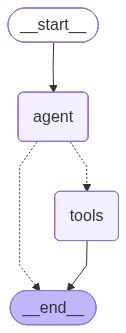

In [313]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [319]:
app.invoke({"messages": ["Hi,Good Evening?"]})

{'messages': [HumanMessage(content='Hi,Good Evening?', additional_kwargs={}, response_metadata={}, id='4325e56f-4567-4621-b08b-3ac019df396f'),
  AIMessage(content='Good evening. Is there anything I can help you with?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 207, 'total_tokens': 220, 'completion_time': 0.020281775, 'completion_tokens_details': None, 'prompt_time': 0.015041245, 'prompt_tokens_details': None, 'queue_time': 0.338834425, 'total_time': 0.03532302}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d9492c3c54', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8905-1d4f-7632-a3ab-fe9954e5c52a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 207, 'output_tokens': 13, 'total_tokens': 220})]}

In [320]:
app.invoke({"messages": ["What is the weather in SF?"]})

{'messages': [HumanMessage(content='What is the weather in SF?', additional_kwargs={}, response_metadata={}, id='f1625c80-3464-4e0c-83b3-83a7e9a0b9f7'),
  AIMessage(content='<brave_search={"query": "SF weather now"}}<brave_search={"query": "San Francisco weather"}}', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 209, 'total_tokens': 233, 'completion_time': 0.100426506, 'completion_tokens_details': None, 'prompt_time': 0.016251283, 'prompt_tokens_details': None, 'queue_time': 0.051234856, 'total_time': 0.116677789}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8905-3193-7540-aa30-4da5ed73a0a8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 209, 'output_tokens': 24, 'total_tokens': 233})]}

In [321]:
workflow.add_edge("tools", 'agent')


Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [322]:
app = workflow.compile()


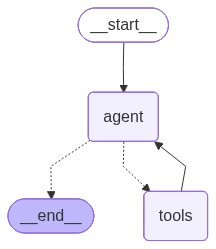

In [323]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [325]:
for output in app.stream({"messages": ["what is the weather in sf"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")


here is output from agent
_______
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'e21p5p4fc', 'function': {'arguments': '{"query":"sf weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 208, 'total_tokens': 222, 'completion_time': 0.026674121, 'completion_tokens_details': None, 'prompt_time': 0.014296372, 'prompt_tokens_details': None, 'queue_time': 0.386212045, 'total_time': 0.040970493}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4848f70c04', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8906-26a0-7182-ac91-68c63cbf9af2-0', tool_calls=[{'name': 'search', 'args': {'query': 'sf weather'}, 'id': 'e21p5p4fc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 208, 'output_tokens': 14, 'total_tokens': 222})]}


here is output from tools
_______
{'messages': [To

In [326]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()


In [327]:
# Define a new graph
workflow3 = StateGraph(MessagesState)

workflow3.add_node("agent", call_model)
workflow3.add_node("tools", tool_node)

workflow3.add_edge(START, "agent")

workflow3.add_conditional_edges("agent",router_function,{"tools": "tools", END: END})

workflow3.add_edge("tools", 'agent')


In [328]:
app3 = workflow3.compile(checkpointer = memory)


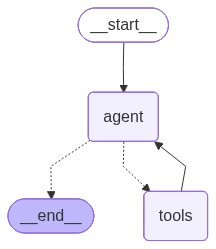

In [329]:
from IPython.display import Image, display

try:
    display(Image(app3.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [330]:
config = {"configurable": {"thread_id": "1"}}


In [331]:
events = app3.stream(
    {"messages": ["Hi there! This is Sarathi."]}, config, stream_mode="values"
)


In [332]:
for event in events:
    event["messages"][-1].pretty_print()


================================ Human Message =================================

Hi there! This is Sarathi.
================================== Ai Message ==================================

Hello Sarathi. How can I assist you today?


In [333]:
events = app3.stream(
    {"messages": ["can you tell me what was my name?"]}, config, stream_mode="values"
)

In [334]:
for event in events:
    event["messages"][-1].pretty_print()


================================ Human Message =================================

can you tell me what was my name?
================================== Ai Message ==================================

Your name is Sarathi.


In [335]:
memory.get(config)

{'v': 4,
 'ts': '2026-06-02T15:51:26.915420+00:00',
 'id': '1f15e9ae-a01c-648f-8004-a06e45777935',
 'channel_versions': {'__start__': '00000000000000000000000000000005.0.5672080133706331',
  'messages': '00000000000000000000000000000006.0.5640605685044361',
  'branch:to:agent': '00000000000000000000000000000006.0.5640605685044361'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000004.0.2844714041736789'},
  'agent': {'branch:to:agent': '00000000000000000000000000000005.0.5672080133706331'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='Hi there! This is Sarathi.', additional_kwargs={}, response_metadata={}, id='0c2c80ee-8128-4d70-8457-9964eb304477'),
   AIMessage(content='Hello Sarathi. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 210, 'total_tokens': 222, 'completion_time': 0.020606855, 'completion_tokens_detail